In [1]:
import os
import shutil
from pathlib import Path

import pyvista as pv
import ogstools as ot
import ogstools.variables as ov

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meshing import create_cube_mesh_p
from functions import pwd_ps,step_rate_s, scale_and_smooth, pickings

# Path

In [59]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

# Point-source and model performance

## Point-source analytical

In [163]:

k=5.35e-12
q=0.00016 #positive for production

ddict={"p_i":0,
       "mu":1e-3 ,
       "B":1,
       "por":0.1,
       "c_t":4.37e-7 ,
       "r_w":0.05,
      }

def time_stepping_congruent(t_initial, t_final, n=50, bias_ratio=0.5): #produces OGS timestepping  congruently simultaneously
    t_split = t_final * 0.2
    n_start = max(2, int(n * bias_ratio))
    n_end = n - n_start + 1
    
    r1 = int(n_start - 1)
    r2 = int(n_end - 1)
    dt1 = (t_split - t_initial) / r1
    dt2 = (t_final - t_split) / r2
    
    t_segment1 = t_initial + np.arange(n_start) * dt1
    t_segment2 = t_split + np.arange(1, n_end) * dt2
    t_a = np.concatenate([t_segment1, t_segment2])
    
    t_a[-1] = t_final 
    return t_a, (r1, dt1), (r2, dt2)

t_initial=0
t_final=500
t_initial_offset = 1e-10 
t, ts1, ts2 = time_stepping_congruent(t_initial, t_final, 50)

rgeo=np.geomspace(1, 12.5, 6).round(2)

rinv=np.sqrt(k*max(t)/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n','"unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Investigation radius (m):  7.82 
 "unperturbed" threshold (m):  31.30


In [164]:
#Point source
r_col=rgeo
pi, mu, B,rw= ddict['p_i'], ddict['mu'], ddict['B'],ddict['r_w']

C_vec = (mu * B) / (4 * np.pi * k * rw)
term1_matrix = pwd_ps(t, ddict, k, r_col) 

p_wsr = pi - (C_vec * q * term1_matrix)

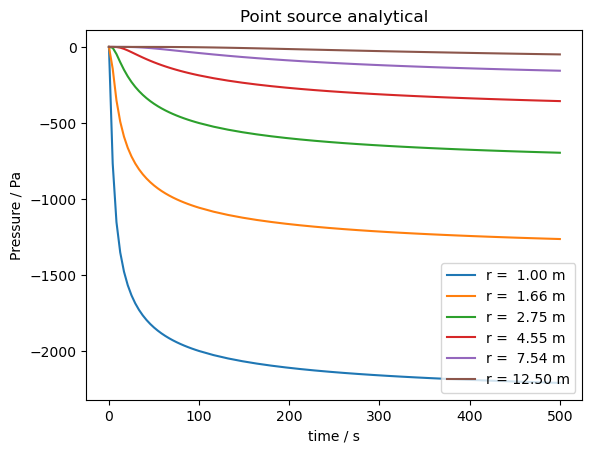

In [165]:
line_labels = [f"r = {val:>5.2f} m" for val in rgeo]

fig0, ax=plt.subplots()
ax.plot(t, p_wsr,label=line_labels) 

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / Pa")
plt.title("Point source analytical")

plt.legend()
#plt.savefig("psa_3D_Ca.pdf", format="pdf") 
plt.pause(1)

## Point-source numerical

### Meshing 3D point-source

In [70]:
cube_file = MESH_DIR / "cube_3d_ps.msh"

create_cube_mesh_p(
    cube_file,
    width= 50,
    height= 50,
    thickness=50,
    mesh_size= 2, #optimal one-size-to-mesh ratio= 20-40, ie, side(50)/mesh_size(2)=25, ref 1
    target_rw= 0.05, # Added target_rw for explicit control
    center_z= -50,
    debug_gui= False,
    local_ref= True,
    ) 

cube_meshes = ot.meshes_from_gmsh(cube_file, log=False)
for name, mesh in cube_meshes.items():
    vtu = MESH_DIR / f"cube_{name}.vtu"
    pv.save_meshio(vtu, mesh)
    print(f"Saved {vtu}")


Saved _out\mesh\cube_domain.vtu
Saved _out\mesh\cube_physical_group_points.vtu
Saved _out\mesh\cube_physical_group_center.vtu
Saved _out\mesh\cube_physical_group_edges.vtu
Saved _out\mesh\cube_physical_group_bottom.vtu
Saved _out\mesh\cube_physical_group_top.vtu
Saved _out\mesh\cube_physical_group_back.vtu
Saved _out\mesh\cube_physical_group_front.vtu
Saved _out\mesh\cube_physical_group_left.vtu
Saved _out\mesh\cube_physical_group_right.vtu
Saved _out\mesh\cube_physical_group_volume.vtu


In [63]:
#slcaing meshing first round of tetrahedra
x=50
y=50
z=-50

point_idx = mesh.find_closest_point([x, y, z])
cell_ids = mesh.extract_points([point_idx])["vtkOriginalCellIds"]

refined_cells = mesh.extract_cells(cell_ids)
local_volume = refined_cells.volume

r_eq = (3 * local_volume / (4 * np.pi))**(1/3)
q_fact=(1/r_eq)**(2/3)

### PRJ file pre-procesing

In [155]:
PROJECT_BASENAME = "Point_source_3Dtest" 
prj_in = Path(f"{PROJECT_BASENAME}.prj")
prj_out = OUT_DIR / f"{PROJECT_BASENAME}_updated.prj"

prj = ot.Project(input_file=prj_in, output_file=prj_out)

In [156]:
#permeability ref numerical
k_ref= 5.35e-12
ct_ref= ddict["c_t"]*ddict['por']

In [157]:
parent_xpath = "./processes/process[1]"
target_path = "./processes/process[1]/equation_balance_type"

mode='volume'

def f_mode(mode:str):
    if mode=="volume":       
            prj.replace_text("volume", xpath=target_path)
    elif mode=="mass":       
            prj.replace_text("mass", xpath=target_path)
    else:
        print("Input just: mass or volume")

    print(f"Updated: Existing equation_balance_type changed to {mode}.")
    

try:
    root = prj.tree.getroot()
    node = root.find(target_path)
    
    if node is not None:
        if node.text == "volume":
            print("Verified: equation_balance_type 'volume' already exists.")
       
        elif node.text=="mass":
            print("Verified: equation_balance_type 'mass' already exists.")
        
        else:
            f_mode(mode)
    else:
        print(f"Adding equation_balance_type={mode}")
        prj.add_element(
            parent_xpath=parent_xpath, 
            tag="equation_balance_type", 
            text=mode
        )

except Exception as e:
    print(f"Error: {e}")

Adding equation_balance_type=volume


In [158]:
q_in=-1*q*q_fact #changing to proudction OGS, scaling the flow to 1st-ring-mesh
if mode=="mass":
    q_in=q_in*1000 #water density

try:
    prj.replace_parameter_value(name="p0", value=ddict["p_i"])
    prj.replace_parameter_value(name="pi_inf", value=ddict["p_i"])
    prj.replace_parameter_value(name="q_in", value=q_in)

    mid=0
    prj.replace_phase_property_value(mediumid=mid, phase="AqueousLiquid", name="viscosity", value=ddict["mu"])
    
    prj.replace_medium_property_value(mediumid=mid, name="porosity", value=ddict["por"])
    prj.replace_medium_property_value(mediumid=mid, name="permeability", value=k_ref)
    prj.replace_medium_property_value(mediumid=mid, name="storage", value= ct_ref)

    print("media/properties, Parameters updated")
except Exception as e:
    print(f"Error occurred: {e}")
    

media/properties, Parameters updated


In [159]:
#timestepping calculations 
try:
    prj.replace_text(t[0], 
                     xpath="./time_loop/processes/process/time_stepping/t_initial")
    prj.replace_text(t[-1],
                     xpath="./time_loop/processes/process/time_stepping/t_end")
    
    prj.replace_text(ts1[0],
                     xpath="./time_loop/processes/process/time_stepping/timesteps/pair/repeat")
    prj.replace_text(ts1[1], 
        xpath="./time_loop/processes/process/time_stepping/timesteps/pair/delta_t")

    prj.add_block( #new block to cover resolution
    blocktag="pair",
    parent_xpath="./time_loop/processes/process/time_stepping/timesteps",
    taglist=["repeat", "delta_t"],
    textlist=[ts2[0], ts2[1]]  
     )
    print('time stepping calculation repeat/delta_t', ts1, '\t', ts2)

    #out 
    prj.replace_text(ts1[0],
                     xpath="./time_loop/output/timesteps/pair/repeat")
    prj.replace_text('1', 
                    xpath="./time_loop/output/timesteps/pair/each_steps")

    prj.add_block( #new block to cover resolution
    blocktag="pair",
    parent_xpath="./time_loop/output/timesteps",
    taglist=["repeat", "each_steps"],
    textlist=[ts2[0], '1']  
     )
    
    print("ouput_res: timestep/each_steps", ts1, '\t', ts2)
except Exception as e:
    print(f"Error occurred: {e}")

prj.write_input()
print('\n', f"prj update in {prj_out} as {PROJECT_BASENAME}_updated.prj")

Error occurred: -1

 prj update in _out_ps\Point_source_3Dtest_updated.prj as Point_source_3Dtest_updated.prj


### Running OGS 

In [160]:
!ogs ./_out/Point_source_3Dtest_updated.prj -m ./_out/mesh -o ./_out/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-03-19 14:08:32+0100.
info: Eigen use 16 threads
info: Reading project file _out\Point_source_3Dtest_updated.prj.
info: readRasters ...
info: readRasters done
info: ConstantParameter: p0
info: ConstantParameter: pi_inf
info: ConstantParameter: constant_porosity_parameter
info: ConstantParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 0. Step size: 0.
info: [time] Output of timestep 0 took 0.484121 s.
info: Time step #0 took 0.542965 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-03-19 14:08:35+0100.
info: Solve processes.
info: Time step #1 started. Time: 4.166666666666667. Step size: 4.166666666666667.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.435057 s.
info: [time] Applying Dirichlet BCs took 0.0157988 s.
info: ------------------------------------------------------------------
info: *** Eigen solver compute()
info: -> compu

## Results and visualization

### Post-processing 

In [166]:
pvd_path = Path("_out/liquid_ps3d_test.pvd")
ms = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="Pa")

In [167]:
y=25
z=-50

#coords=np.array(np.geomspace([26,y,z],[50,y,z],6).round(2)) #extracting along x geometrically
coords=np.array(np.linspace([26,y,z],[50,y,z],6)) #extracting along x linearly
coords[:,0]=rgeo+25 #adjusting geometry shifting
ms_probes = ms.extract_probe(ms,points=coords)

labels = [f"x={pt[0]:>5.2f}, y={y}, z={z}" for pt in coords]

diff = p_wsr - ms_probes['pressure']



100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.81it/s]


### Performance comparison

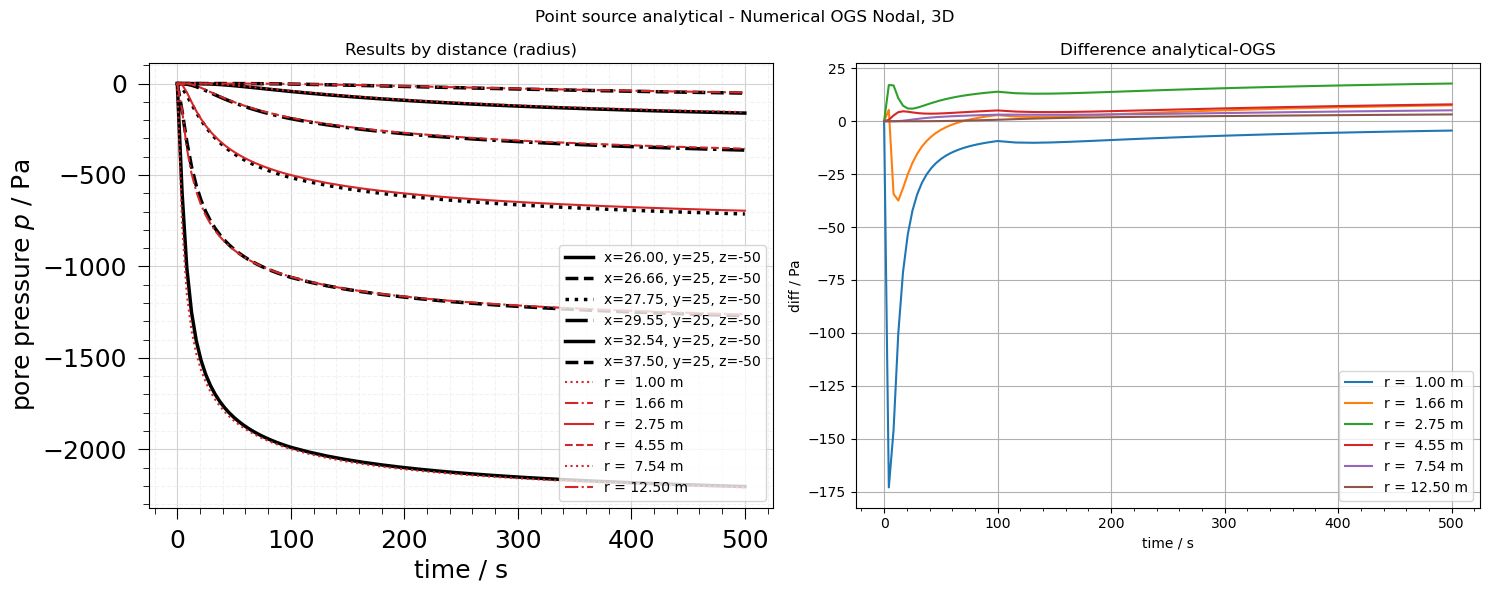

In [169]:
fig, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,6], sharex=True)
ot.plot.line(ms_probes,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels)
axs[0].plot(t, p_wsr,color='tab:red', label=line_labels) 
axs[1].plot(t, diff, label=line_labels)

fig.suptitle("Point source analytical - Numerical OGS Nodal, 3D")
axs[0].set_title("Results by distance (radius)")
axs[1].set_title("Difference analytical-OGS")
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / Pa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

#plt.savefig("psn_3D_Ca.pdf", format="pdf")  
plt.show()

# STIMTEC Example

## Path adjoint

In [83]:
OGS_PATH = None

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out_ps"))
MESH_DIR = OUT_DIR / "mesh"
shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)

## Point-source step-rate

### Preprocesing and preparing data

In [84]:
cwd=Path.cwd()
newpath=cwd/"STIMTEC_example"
dataex=pd.read_csv(newpath/"BH10_20180716_51.6.csv",sep=",",header=0)


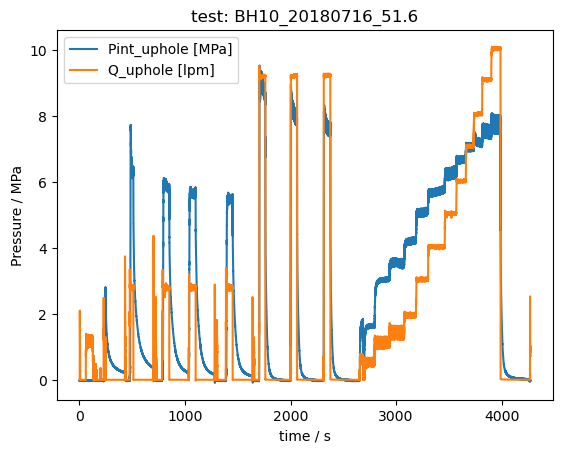

In [85]:
#visualising full data set
fig1, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title("test: BH10_20180716_51.6")

ax.plot(dataex['Zeit [s]'],dataex['Pint_uphole [MPa]'],label="Pint_uphole [MPa]")
ax.plot(dataex['Zeit [s]'],dataex['Q_uphole [lpm]'],label="Q_uphole [lpm]")

plt.legend()
plt.show()

steps 	 15


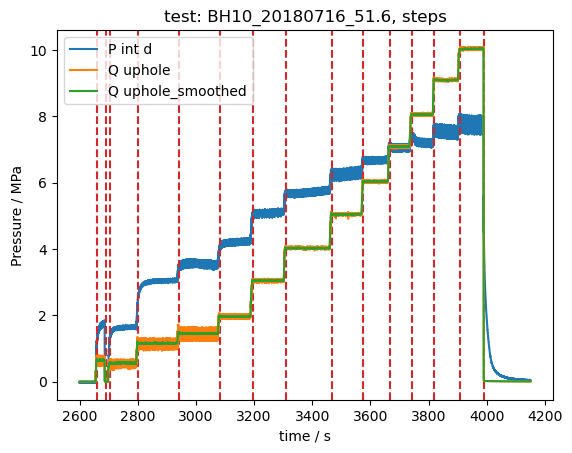

In [86]:
#isolating Step-rate and preparing curve

mask = (dataex['Zeit [s]'] > 2600) & (dataex['Zeit [s]'] < 4150)
dataex_f = dataex.loc[mask, :].copy()
dataex_f = dataex_f.reset_index(drop=True)

dataex_f['Q_uphole [lpm]_s']=scale_and_smooth(dataex_f['Q_uphole [lpm]'])

steps_=pickings(dataex_f['Q_uphole [lpm]_s'],60,20)
print('steps','\t', len(steps_))

fig1, ax=plt.subplots()

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / MPa")
plt.title("test: BH10_20180716_51.6, steps")

ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]'],label="P int d")
for i in range (len(steps_)):
     ax.axvline(x=dataex_f.loc[steps_[i,0],'Zeit [s]'],ls="--",color="tab:red")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_uphole [lpm]'],label="Q uphole")
ax.plot(dataex_f['Zeit [s]'],dataex_f['Q_uphole [lpm]_s'],label="Q uphole_smoothed")

plt.legend()
plt.show()

In [87]:
#protocol
pr=pd.DataFrame(data=steps_,
                      index = np.arange(len(steps_)),
                      columns=['index','qs'])
protocol={'index':0,'qs':dataex_f['Q_uphole [lpm]_s'].values[0],'T_s':dataex_f['Zeit [s]'].values[0]}
pr["T_s"]=dataex_f.loc[steps_[:,0].astype(int),'Zeit [s]'].values
protocol=pd.concat([pd.DataFrame(protocol,index=[0]),pr],axis=0)
protocol.reset_index(drop=True, inplace=True)
protocol['qs']=-protocol['qs']/60000 #injection is negative flow


### Point-source analytical running

In [131]:
#data 
ddict={"p_i":0,
       "mu":1e-3 ,
       "B":1,
       "por":0.030,
       "c_t":4e-8 ,
       "r_w":0.038 
      }

In [140]:
delta_t=dataex_f['Zeit [s]'].values
tp=protocol['T_s'].values
q_array=protocol['qs'].values

r_val1=ddict['r_w'] #at wellbore face
k_val1= np.geomspace(2e-14, 5e-14, 5) #real wellbore

pwsr1= step_rate_s(pwd_ps, delta_t, tp, q_array, ddict, k_val1, r_val1)

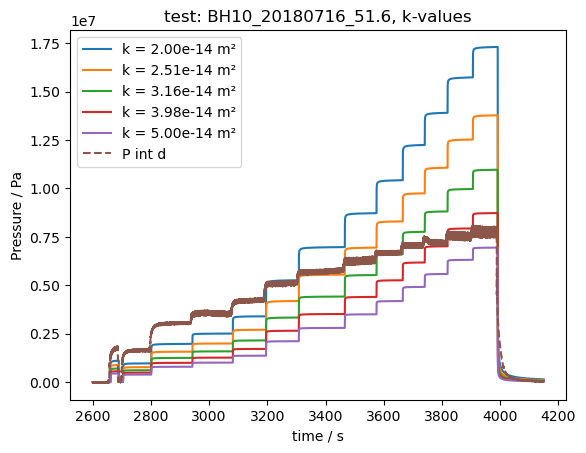

In [141]:
fig2, ax=plt.subplots()

for i, k in enumerate(k_val1):
    ax.plot(delta_t, pwsr1[:, i], label=f'k = {k:.2e} m²')
    
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]']*1e6,label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / Pa")
plt.title("test: BH10_20180716_51.6, k-values")

plt.legend()
plt.pause(1)

In [136]:
k_val=4.5e-14 #reference k

rgeo=np.geomspace(0.038,5,5)
r_val=rgeo
pwsr2= step_rate_s(pwd_ps, delta_t, tp, q_array, ddict, k_val, r_val)

rinv=np.sqrt(k_val*(max(dataex_f['Zeit [s]'])-min(dataex_f['Zeit [s]']))/(ddict['por']*ddict['mu']*ddict['c_t']))
print("Investigation radius (m): ",f"{rinv:.2f}",'\n','"unperturbed" threshold (m): ', f"{4*rinv:.2f}")

Investigation radius (m):  7.62 
 "unperturbed" threshold (m):  30.50


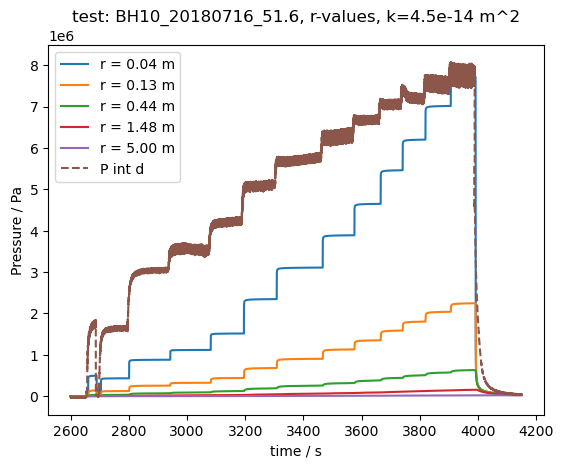

In [144]:
line_labels = [f"r = {val:>5.2f} m" for val in rgeo]

fig3, ax=plt.subplots()

for i, r in enumerate(rgeo):
    plt.plot(delta_t, pwsr2[:, i], label=f'r = {r:.2f} m')
ax.plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]']*1e6,label="P int d", ls="--")

ax.set_xlabel("time / s")
ax.set_ylabel("Pressure / Pa")
plt.title(f"test: BH10_20180716_51.6, r-values, k={k_val} m^2")

plt.legend() 
plt.pause(1)

### Plot report

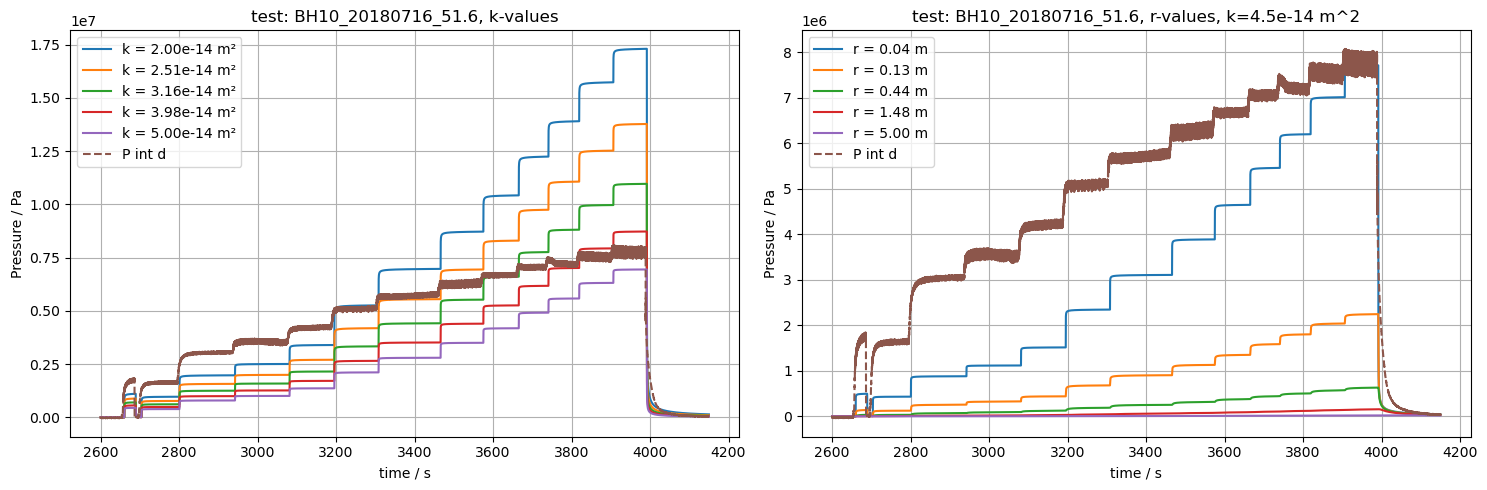

In [151]:
figprint, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,5], sharex=True)

for i, k in enumerate(k_val1):
    axs[0].plot(delta_t, pwsr1[:, i], label=f'k = {k:.2e} m²')
    
axs[0].plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]']*1e6,label="P int d", ls="--")

axs[0].set_xlabel("time / s")
axs[0].set_ylabel("Pressure / Pa")
axs[0].set_title("test: BH10_20180716_51.6, k-values")

line_labels = [f"r = {val:>5.2f} m" for val in rgeo]

for i, r in enumerate(rgeo):
    axs[1].plot(delta_t, pwsr2[:, i], label=f'r = {r:.2f} m')
axs[1].plot(dataex_f['Zeit [s]'],dataex_f['Pint_uphole [MPa]']*1e6,label="P int d", ls="--")

axs[1].set_xlabel("time / s")
axs[1].set_ylabel("Pressure / Pa")
axs[1].set_title(f"test: BH10_20180716_51.6, r-values, k={k_val} m^2")

fig4.suptitle("Point source analytical , r and k values") 

axs[0].legend()
axs[1].legend()
axs[0].grid()
axs[1].grid()
plt.tight_layout()

#plt.savefig("psa_3D_BH10_20180716_51.6.pdf", format="pdf") 
plt.show()

## Point-source Numerical

### Meshing 3D point-source

In [93]:
cube_file = MESH_DIR / "cube_3d_ps.msh"

create_cube_mesh_p(
    cube_file,
    width= 50,
    height= 50,
    thickness=50,
    mesh_size= 2, #optimal one-size-to-mesh ratio= 20-40, ie, side(50)/mesh_size(2)=25, ref 1
    target_rw= 0.05, # Added target_rw for explicit control
    center_z= -50,
    debug_gui= False,
    local_ref= True,
    ) 

cube_meshes = ot.meshes_from_gmsh(cube_file, log=False)
for name, mesh in cube_meshes.items():
    vtu = MESH_DIR / f"cube_{name}.vtu"
    pv.save_meshio(vtu, mesh)
    print(f"Saved {vtu}")


Saved _out_ps\mesh\cube_domain.vtu
Saved _out_ps\mesh\cube_physical_group_points.vtu
Saved _out_ps\mesh\cube_physical_group_center.vtu
Saved _out_ps\mesh\cube_physical_group_edges.vtu
Saved _out_ps\mesh\cube_physical_group_bottom.vtu
Saved _out_ps\mesh\cube_physical_group_top.vtu
Saved _out_ps\mesh\cube_physical_group_back.vtu
Saved _out_ps\mesh\cube_physical_group_front.vtu
Saved _out_ps\mesh\cube_physical_group_left.vtu
Saved _out_ps\mesh\cube_physical_group_right.vtu
Saved _out_ps\mesh\cube_physical_group_volume.vtu


In [94]:
#slcaing meshing first round of tetrahedra
x=50
y=50
z=-50

point_idx = mesh.find_closest_point([x, y, z])
cell_ids = mesh.extract_points([point_idx])["vtkOriginalCellIds"]

refined_cells = mesh.extract_cells(cell_ids)
local_volume = refined_cells.volume

r_eq = (3 * local_volume / (4 * np.pi))**(1/3)
q_fact=(1/r_eq)**(2/3)

### PRJ file pre-procesing

In [95]:
PROJECT_BASENAME = "Point_source_3Dtest" 
TESTSR= "BH10_20180716_51.6"
prj_in = Path(f"{PROJECT_BASENAME}.prj")
prj_out = OUT_DIR / f"{TESTSR}_PS3D.prj"

prj = ot.Project(input_file=prj_in, output_file=prj_out)

In [96]:
#Permeability reference and pressure pi, pinf
k_ref= 4.5e-14
ct_ref= ddict["c_t"]*ddict['por']

p_inf=0
p0=0

In [97]:
parent_xpath = "./processes/process[1]"
target_path = "./processes/process[1]/equation_balance_type"

mode='volume'

def f_mode(mode:str):
    if mode=="volume":       
            prj.replace_text("volume", xpath=target_path)
    elif mode=="mass":       
            prj.replace_text("mass", xpath=target_path)
    else:
        print("Input just: mass or volume")

    print(f"Updated: Existing equation_balance_type changed to {mode}.")
    

try:
    root = prj.tree.getroot()
    node = root.find(target_path)
    
    if node is not None:
        if node.text == "volume":
            print("Verified: equation_balance_type 'volume' already exists.")
       
        elif node.text=="mass":
            print("Verified: equation_balance_type 'mass' already exists.")
        
        else:
            f_mode(mode)
    else:
        print(f"Adding equation_balance_type={mode}")
        prj.add_element(
            parent_xpath=parent_xpath, 
            tag="equation_balance_type", 
            text=mode
        )

except Exception as e:
    print(f"Error: {e}")

Adding equation_balance_type=volume


In [98]:
last_t=dataex_f.loc[dataex_f.tail(1).index.values.astype(int),'Zeit [s]':'Q_uphole [lpm]']
last_t['Q_uphole [lpm]']=last_t['Q_uphole [lpm]']/60000
last_t=last_t.values.flatten().tolist() 
print(last_t)

param_name = "q_in" #inlet flow

def create_sr_ogs(T,q,data,mode=mode,factor=q_fact,var="t"):
    q_scaled = -q * factor
    q_last_scaled = data[1] * factor 
    
    q_list = q_scaled.tolist()
    q_list.append(q_last_scaled)
    
    T_list = T.tolist()
    T_list.append(data[0])


    if mode == "mass":
        q_list = [val * 1000 for val in q_list]
        
    parts = [f"{var} < {T_list[i+1]:g} ? {q_list[i]:.6g} :" for i in range(0, len(T_list)-1)]
    
    return "(" + "\n           ".join(parts) + f"\n           {q_list[-1]:.6g})",T_list

try:
    prj.replace_parameter_value(name="p0", value=p0)
    prj.replace_parameter_value(name="pi_inf", value=p_inf)
    
    root = prj.tree.getroot() # Access the underlying ElementTree
    param_node = root.find(f".//parameters/parameter[name='{param_name}']")
    value_tag = param_node.find("value")
    if value_tag is not None:
         param_node.remove(value_tag)
    
    n_type = prj.replace_text(
        "Function", xpath=f".//parameters/parameter[name='{param_name}']/type"
    )
    
    n_expr,Times = create_sr_ogs(tp,q_array,last_t,mode)
    
    prj.add_element(
        parent_xpath=f".//parameters/parameter[name='{param_name}']", 
        tag="expression", 
        text=n_expr
    )
    
    print("flow_expression", n_expr)
    
    #timestepping calculations 
    delta_res=1
    prj.replace_text(Times[0], 
                     xpath="./time_loop/processes/process/time_stepping/t_initial")
    prj.replace_text(Times[-1],
                     xpath="./time_loop/processes/process/time_stepping/t_end")
    prj.replace_text("1",
                     xpath="./time_loop/processes/process/time_stepping/timesteps/pair/repeat")
    prj.replace_text(delta_res, #resolution of stepping
        xpath="./time_loop/processes/process/time_stepping/timesteps/pair/delta_t")
    
    print("delta_t calculation: ", delta_res)

    #out and prefix
    outsteps=10 #10 at convenience
    prefix= TESTSR
    
    prj.replace_text("1",
                     xpath="./time_loop/output/timesteps/pair/repeat")
    prj.replace_text(outsteps, #resolution of stepping
                    xpath="./time_loop/output/timesteps/pair/each_steps")
    prj.replace_text(prefix, 
                     xpath="./time_loop/output/prefix")
    
    print("ouput_res: ", outsteps,'\n','prefix:',prefix )
    
    mid=0
    prj.replace_phase_property_value(mediumid=mid, phase="AqueousLiquid", name="viscosity", value=ddict["mu"])
    
    prj.replace_medium_property_value(mediumid=mid, name="porosity", value=ddict["por"])
    prj.replace_medium_property_value(mediumid=mid, name="permeability", value=k_ref)
    prj.replace_medium_property_value(mediumid=mid, name="storage", value=ct_ref)
    
    print("media/properties, Parameters updated")
    
except Exception as e:
    
    print(f"Error occurred: {e}")

prj.write_input()
print('\n', f"prj update in {prj_in} as {prj_out}")

[4149.973, 5.675e-08]
flow_expression (t < 2659.97 ? 2.33588e-08 :
           t < 2689.27 ? 1.13959e-05 :
           t < 2703.72 ? -5.2505e-09 :
           t < 2800.72 ? 9.8177e-06 :
           t < 2942.27 ? 1.99673e-05 :
           t < 3081.27 ? 2.52986e-05 :
           t < 3195.37 ? 3.42849e-05 :
           t < 3308.12 ? 5.3118e-05 :
           t < 3466.22 ? 7.02932e-05 :
           t < 3575.17 ? 8.79515e-05 :
           t < 3665.42 ? 0.000105134 :
           t < 3741.02 ? 0.000123523 :
           t < 3819.37 ? 0.000140232 :
           t < 3906.42 ? 0.000158601 :
           t < 3991.77 ? 0.00017438 :
           t < 4149.97 ? 3.03149e-07 :
           5.93407e-08)
delta_t calculation:  1
ouput_res:  1 
 prefix: BH10_20180716_51.6
media/properties, Parameters updated

 prj update in Point_source_3Dtest.prj as _out_ps\BH10_20180716_51.6_PS3D.prj


### Running OGS

In [99]:
!ogs _out_ps\BH10_20180716_51.6_PS3D.prj -m ./_out_ps/mesh -o ./_out_ps/

info: This is OpenGeoSys-6 version 6.5.5.
info: OGS started on 2026-03-19 11:45:32+0100.
info: Eigen use 16 threads
info: Reading project file _out_ps\BH10_20180716_51.6_PS3D.prj.
info: readRasters ...
info: readRasters done
info: ConstantParameter: p0
info: ConstantParameter: pi_inf
info: ConstantParameter: constant_porosity_parameter
info: FunctionParameter: q_in
info: Initialize processes.
info: Time step #0 started. Time: 2600.023. Step size: 0.
info: [time] Output of timestep 0 took 0.290475 s.
info: Time step #0 took 0.324525 s.
info: OpenGeoSys is now initialized.
info: OGS started on 2026-03-19 11:45:34+0100.
info: Solve processes.
info: Time step #1 started. Time: 2601.0230000000001. Step size: 1.
info: Solving process #0 started.
info: Iteration #1 started.
info: [time] Assembly took 0.27954 s.
info: [time] Applying Dirichlet BCs took 0.0087097 s.
info: ------------------------------------------------------------------
info: *** Eigen solver compute()
info: -> compute with Ei

## Results and visualization

### Post-processing 

In [100]:
pvd_path = Path("_out_ps/BH10_20180716_51.6.pvd")
ms = ot.MeshSeries(pvd_path)
pressure=ot.variables.pressure
pressure= pressure.replace(output_unit="Pa")

In [101]:
y=25
z=-50

np.geomspace(0.038,5,5)

coords=np.array(np.linspace([25,y,z],[50,y,z],5)) #extracting along x linearly
coords[:,0]=rgeo+25 #adjusting geometry shifting
ms_probes = ms.extract_probe(ms,points=coords)

labels = [f"x={pt[0]:>5.2f}, y={y}, z={z}" for pt in coords]

pwsr2p= step_rate_s(pwd_ps, ms_probes.timevalues, tp, q_array, ddict, k_val, r_val) #diff by time resolution
diff = pwsr2p - ms_probes['pressure']


100%|██████████████████████████████████████████████████████████████████████████████| 1551/1551 [01:46<00:00, 14.52it/s]


### Analytical and Numerical OGS comparison

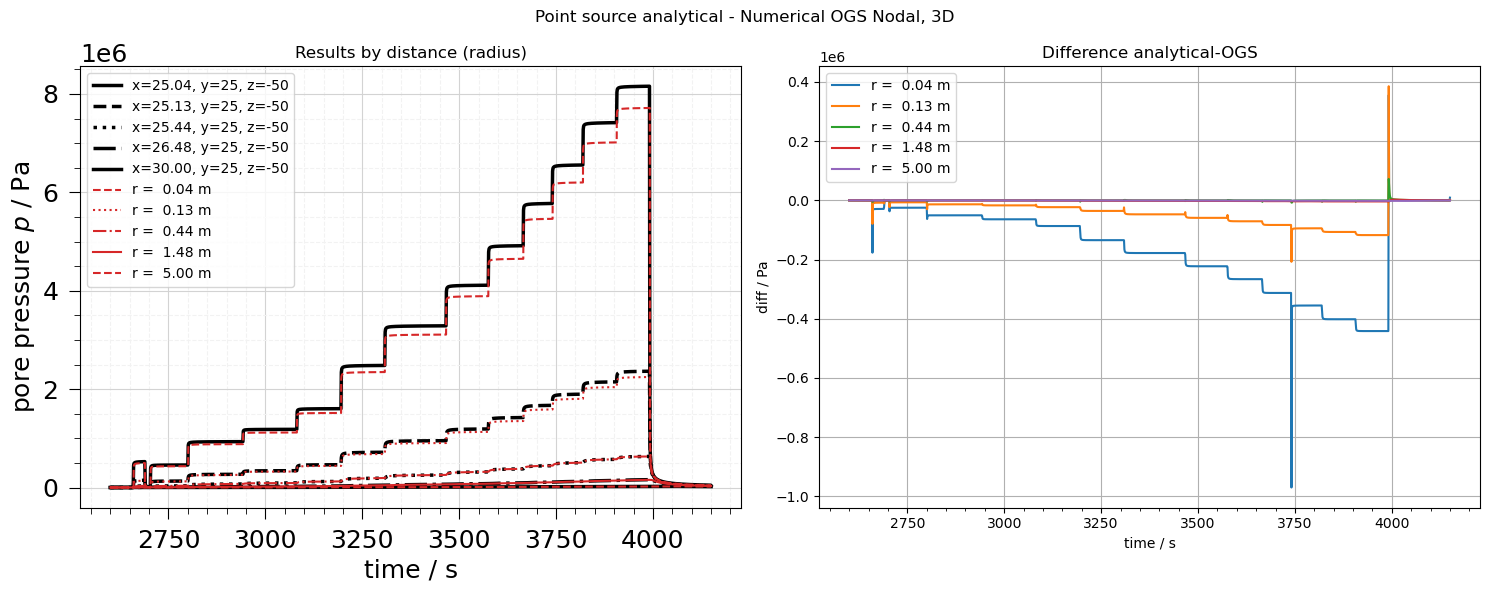

In [153]:
t=dataex_f['Zeit [s]']

fig4, axs= plt.subplots(nrows=1, ncols=2,figsize=[15,6], sharex=True)
ot.plot.line(ms_probes,"time", pressure,ax=axs[0], color='k',fontsize=18,label=labels)
axs[0].plot(t, pwsr2,color='tab:red', label=line_labels) 
axs[1].plot(ms_probes.timevalues, diff, label=line_labels)

fig4.suptitle("Point source analytical - Numerical OGS Nodal, 3D") 
axs[0].set_title("Results by distance (radius)")
axs[1].set_title("Difference analytical-OGS")
axs[1].set_xlabel("time / s")
axs[1].set_ylabel("diff / Pa")

axs[0].legend()
axs[1].legend()
axs[1].grid()
plt.tight_layout()

#plt.savefig("psn_3D_BH10_20180716_51.6.pdf", format="pdf") 
plt.show()

**NOTE: Numerical difference is due to mesh and rw relations.
The specific storage capacity (OGS) scaling is equal to $$s=c* \phi, \quad \left[\mathrm{Pa^{-1}}\right]$$, the scaling for the flow is $$r_{\mathrm{eq}} = (3 * LV / (4 \pi))^{1/3}$$ 
$$q_{\mathrm{fact}}=(1/r_{\mathrm{eq}})^{2/3}$$ 
$$q_{\mathrm{num}}=q_{\mathrm{fact}} \, q_{\mathrm{an}}$$ 
Where $LV$ is the local volume of the first ring of elements in around the node source; $q_{\mathrm{num}}\, , q_{\mathrm{fact}} \, , q_{\mathrm{an}}$, are the numerical (for OGS), factor, and analytical flow input.